In [3]:
# Imports and basic config

import os
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [4]:
#  Project configuration

CONFIG = {
    "DATA_DIR": r"E:\Medical Project\brisc2025\classification_task",  # <-- adjust if needed
    "IMG_SIZE": (224, 224),
    "BATCH_SIZE": 32,
    "SEED": 42,
    "EPOCHS_HEAD": 10,      # epochs for training the new classification head
    "EPOCHS_FINE_TUNE": 5,  # epochs for fine-tuning
    "LEARNING_RATE_HEAD": 1e-4,
    "LEARNING_RATE_FINE_TUNE": 1e-5,
}

train_dir = os.path.join(CONFIG["DATA_DIR"], "train")
test_dir = os.path.join(CONFIG["DATA_DIR"], "test")

print("Train dir:", train_dir)
print("Test dir:", test_dir)
print("Train exists?", os.path.exists(train_dir))
print("Test exists?", os.path.exists(test_dir))

Train dir: E:\Medical Project\brisc2025\classification_task\train
Test dir: E:\Medical Project\brisc2025\classification_task\test
Train exists? True
Test exists? True


In [5]:
# ======================================
# 3) Create train, validation and test datasets
# ======================================

# Train + Validation from the same 'train' folder using validation_split
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="training",
    seed=CONFIG["SEED"],
    image_size=CONFIG["IMG_SIZE"],
    batch_size=CONFIG["BATCH_SIZE"]
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="validation",
    seed=CONFIG["SEED"],
    image_size=CONFIG["IMG_SIZE"],
    batch_size=CONFIG["BATCH_SIZE"]
)

# Separate test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=CONFIG["IMG_SIZE"],
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False  # important for evaluation
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

# Optimize datasets for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 5000 files belonging to 4 classes.
Using 4250 files for training.
Found 5000 files belonging to 4 classes.
Using 750 files for validation.
Found 1000 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


In [6]:

# 4) Compute class weights (same logic as Person 1)


# Collect labels from the train directory to compute class weights
all_train_labels = []
for class_index, class_name in enumerate(sorted(os.listdir(train_dir))):
    class_path = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    num_images = len([
        fname for fname in os.listdir(class_path)
        if fname.lower().endswith((".png", ".jpg", ".jpeg"))
    ])
    all_train_labels.extend([class_index] * num_images)

all_train_labels = np.array(all_train_labels)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_train_labels),
    y=all_train_labels
)

class_weight_dict = {
    i: w for i, w in enumerate(class_weight_values)
}

print("Class weights:", class_weight_dict)


Class weights: {0: 1.0897994768962511, 1: 0.9405568096313017, 2: 1.1715089034676665, 3: 0.8579272477693891}


In [7]:
# 5) Data augmentation layer


data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", name="random_flip"),
        layers.RandomRotation(0.05, name="random_rotation"),
        layers.RandomZoom(0.05, name="random_zoom"),
    ],
    name="data_augmentation"
)

In [16]:

# 6) Build Transfer Learning model (ResNet50)
# ======================================

def build_resnet_transfer_model(num_classes, img_size=(224, 224)):
    # Input layer
    inputs = keras.Input(shape=img_size + (3,), name="input_image")

    # Data augmentation
    x = data_augmentation(inputs)

    # ResNet50 preprocessing (ImageNet style)
    x = preprocess_input(x)

    # Base ResNet50 model (pretrained on ImageNet)
    base_model = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=img_size + (3,),
    )
    base_model.trainable = False  # freeze base model for head training

    x = base_model(x, training=False)  # important when base_model is frozen

    # Global pooling + dropout + final dense
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(0.3, name="dropout")(x)
    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="predictions"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="resnet50_transfer")

    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=CONFIG["LEARNING_RATE_HEAD"]),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model, base_model

resnet_model, base_model = build_resnet_transfer_model(num_classes, CONFIG["IMG_SIZE"])
resnet_model.summary()


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 4)         │      8,196 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [17]:

# 7) Train only the new classification head (base_model frozen)


early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

history_head = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["EPOCHS_HEAD"],
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr]
)


Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.4242 - loss: 1.3527 - val_accuracy: 0.6507 - val_loss: 0.9249 - learning_rate: 1.0000e-04
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.6315 - loss: 0.8836 - val_accuracy: 0.7653 - val_loss: 0.6598 - learning_rate: 1.0000e-04
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.7275 - loss: 0.7081 - val_accuracy: 0.8093 - val_loss: 0.5517 - learning_rate: 1.0000e-04
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.7621 - loss: 0.6262 - val_accuracy: 0.8240 - val_loss: 0.4939 - learning_rate: 1.0000e-04
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.7932 - loss: 0.5477 - val_accuracy: 0.8387 - val_loss: 0.4509 - learning_rate: 1.0000e-04
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.8125 - loss: 0.5127 - val_accuracy: 0.8520 - val_loss: 0.4229 - learning_rate: 1.0000e-04
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - acc

In [37]:
resnet_model.save("resnet_transfer_head.keras")


In [29]:

# 8) Fine-tuning the last part of ResNet50


# Unfreeze the base model
base_model.trainable = True

# Optionally, keep most of the layers frozen and unfreeze only the last block
# You can tune this number based on overfitting/underfitting
fine_tune_at = int(len(base_model.layers) * 0.7)  # unfreeze last 30% of layers

for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        layer.trainable = True

print("Total layers in base_model:", len(base_model.layers))
print("Fine-tuning from layer index:", fine_tune_at)

# Re-compile the model with a lower learning rate
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CONFIG["LEARNING_RATE_FINE_TUNE"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Optional: you can re-use the same callbacks
fine_tune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
]

history_finetune = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["EPOCHS_FINE_TUNE"],
    class_weight=class_weight_dict,
    callbacks=fine_tune_callbacks
)




Total layers in base_model: 175
Fine-tuning from layer index: 122
Epoch 1/5
  9/133 ━━━━━━━━━━━━━━━━━━━━ 4:02 2s/step - accuracy: 0.9928 - loss: 0.0516

KeyboardInterrupt: 

In [31]:
# Save final fine-tuned model
resnet_model.save("resnet_transfer_finetuned.keras")


In [30]:
# ======================================
# 9) Evaluation on the test set
# ======================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Collect all predictions and true labels from test_ds
y_true = []
y_pred = []

for images, labels in test_ds:
    # Predict probabilities
    preds = resnet_model.predict(images, verbose=0)
    # Convert to class indices
    pred_labels = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute accuracy
test_accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy (Transfer Learning + Fine-tune):", test_accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


Test Accuracy (Transfer Learning + Fine-tune): 0.948

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.91      0.94       254
  meningioma       0.92      0.92      0.92       306
    no_tumor       0.96      1.00      0.98       140
   pituitary       0.94      0.98      0.96       300

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000

Confusion Matrix:
 [[230  20   0   4]
 [  3 283   6  14]
 [  0   0 140   0]
 [  0   5   0 295]]


In [24]:
# Inspect last layers inside base ResNet50 to confirm the conv layer name
base_model = resnet_model.get_layer("resnet50")
print([layer.name for layer in base_model.layers[-10:]])


['conv5_block3_1_conv', 'conv5_block3_1_bn', 'conv5_block3_1_relu', 'conv5_block3_2_conv', 'conv5_block3_2_bn', 'conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_3_bn', 'conv5_block3_add', 'conv5_block3_out']


In [34]:
# %%
# 10) Build a classifier model on top of the last conv layer + Grad-CAM utilities

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow import keras

# Name of the last conv layer inside base ResNet50
last_conv_layer_name = "conv5_block3_out"

# Get the last conv layer from the base model
last_conv_layer = base_model.get_layer(last_conv_layer_name)

# Get the head layers from the full model
gap_layer = resnet_model.get_layer("global_avg_pool")
drop_layer = resnet_model.get_layer("dropout")
pred_layer = resnet_model.get_layer("predictions")

# Build a classifier model that takes the last conv feature maps and outputs class scores
classifier_input = keras.Input(shape=last_conv_layer.output.shape[1:])
x = gap_layer(classifier_input)
x = drop_layer(x, training=False)  # we don't want dropout randomness during Grad-CAM
output_scores = pred_layer(x)

classifier_model = keras.Model(
    classifier_input,
    output_scores,
    name="gradcam_classifier"
)

def make_gradcam_heatmap(
    img_array,
    data_augmentation,
    base_model,
    classifier_model,
    last_conv_layer_name,
    pred_index=None
):
    """
    Generate a Grad-CAM heatmap for a given image and class index.

    img_array: 4D tensor (1, H, W, 3) as coming from the dataset (no manual preprocessing).
    data_augmentation: augmentation model used during training.
    base_model: ResNet50 backbone.
    classifier_model: small model that maps conv feature maps -> class scores.
    last_conv_layer_name: name of the last conv layer inside base_model.
    pred_index: class index to explain; if None, use the top predicted class.
    """

    # 1) Build a model that maps preprocessed images to the last conv feature maps
    last_conv_layer = base_model.get_layer(last_conv_layer_name)
    last_conv_layer_model = keras.Model(
        inputs=base_model.input,
        outputs=last_conv_layer.output
    )

    with tf.GradientTape() as tape:
        # a) Apply the same augmentation (but no randomness in training=False)
        x = data_augmentation(img_array, training=False)
        # b) Apply the same ResNet50 preprocessing
        x = preprocess_input(x)
        # c) Forward pass through the backbone until last conv layer
        conv_outputs = last_conv_layer_model(x)
        # d) Forward pass through the classifier head
        preds = classifier_model(conv_outputs, training=False)

        if pred_index is None:
            pred_index = tf.argmax(preds[0])

        class_channel = preds[:, pred_index]

    # 2) Gradient of the class score w.r.t. conv outputs
    grads = tape.gradient(class_channel, conv_outputs)  # shape: (1, H', W', C)

    # 3) Global average pooling of gradients over spatial dimensions
    pooled_grads = tf.reduce_mean(grads[0], axis=(0, 1))  # shape: (C,)

    conv_outputs = conv_outputs[0]  # shape: (H', W', C)

    # 4) Weighted sum of feature maps
    heatmap = tf.reduce_sum(pooled_grads * conv_outputs, axis=-1)  # shape: (H', W')

    # 5) Apply ReLU
    heatmap = tf.nn.relu(heatmap)

    # 6) Normalize heatmap to [0, 1]
    max_val = tf.reduce_max(heatmap) + 1e-8
    heatmap /= max_val

    return heatmap.numpy()


def resize_heatmap_to_image(heatmap, target_size):
    """
    Resize a 2D heatmap to match target image size (H, W).
    """
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        target_size
    ).numpy().squeeze()
    return heatmap_resized


def blend_heatmap_with_image(original_image, heatmap_resized, alpha=0.4):
    """
    Blend the original RGB image with the colored heatmap.

    original_image: np.array of shape (H, W, 3), values in [0, 255] or [0, 1].
    heatmap_resized: 2D array of shape (H, W), with values in [0, 1].
    alpha: blending factor between original image and Grad-CAM heatmap.
    """

    # Ensure image is in uint8 [0, 255]
    if original_image.dtype != np.uint8:
        img = np.clip(original_image, 0, 255)
        img = img.astype("uint8")
    else:
        img = original_image

    # Apply colormap on heatmap
    colormap = cm.get_cmap("jet")
    heatmap_color = colormap(heatmap_resized)[:, :, :3]  # drop alpha channel
    heatmap_color = np.uint8(255 * heatmap_color)

    # Blend original image + heatmap
    img = img.astype("float32")
    heatmap_color = heatmap_color.astype("float32")

    blended = img * (1.0 - alpha) + heatmap_color * alpha
    blended = np.clip(blended, 0, 255).astype("uint8")

    return blended


True label index: 0 -> glioma
Predicted label index: 0 -> glioma


C:\Users\msi\AppData\Local\Temp\ipykernel_15692\4207160572.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


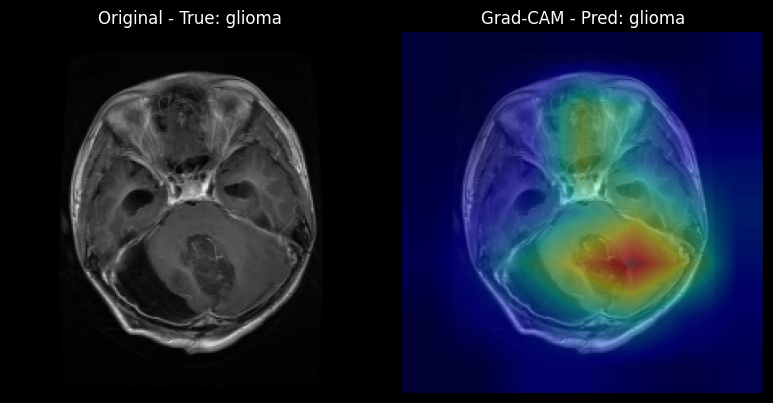

Saved Grad-CAM image to: outputs\gradcam\gradcam_true-glioma_pred-glioma.png


In [36]:
# %%
# 11) Grad-CAM example on a single test image + saving the result

from pathlib import Path

# Take one batch from the test dataset
test_batch = next(iter(test_ds))
test_images, test_labels = test_batch

# Choose an index inside this batch
idx = 0  # you can change this index to visualize another image

# Prepare single image (keep batch dimension)
img_tensor = test_images[idx:idx+1]  # shape: (1, H, W, 3)
true_label_idx = int(test_labels[idx].numpy())
true_label_name = class_names[true_label_idx]

print("True label index:", true_label_idx, "->", true_label_name)

# Predict with the trained model (for info only)
pred_probs = resnet_model.predict(img_tensor, verbose=0)
pred_label_idx = int(np.argmax(pred_probs[0]))
pred_label_name = class_names[pred_label_idx]

print("Predicted label index:", pred_label_idx, "->", pred_label_name)

# 1) Generate Grad-CAM heatmap for the predicted class
heatmap = make_gradcam_heatmap(
    img_array=img_tensor,
    data_augmentation=data_augmentation,
    base_model=base_model,
    classifier_model=classifier_model,
    last_conv_layer_name=last_conv_layer_name,
    pred_index=pred_label_idx
)

# 2) Resize heatmap to match the image size
h, w = img_tensor.shape[1], img_tensor.shape[2]
heatmap_resized = resize_heatmap_to_image(heatmap, (h, w))

# 3) Original image as NumPy
original_img = img_tensor[0].numpy()

# 4) Blend Grad-CAM with original image
gradcam_image = blend_heatmap_with_image(original_img, heatmap_resized, alpha=0.4)

# 5) Plot original vs Grad-CAM
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title(f"Original - True: {true_label_name}")
plt.axis("off")
plt.imshow(original_img.astype("uint8"))

plt.subplot(1, 2, 2)
plt.title(f"Grad-CAM - Pred: {pred_label_name}")
plt.axis("off")
plt.imshow(gradcam_image)

plt.tight_layout()
plt.show()

# 6) Save Grad-CAM image to disk
output_dir = Path("outputs/gradcam")
output_dir.mkdir(parents=True, exist_ok=True)

save_path = output_dir / f"gradcam_true-{true_label_name}_pred-{pred_label_name}.png"
plt.imsave(save_path, gradcam_image)
print("Saved Grad-CAM image to:", save_path)


In [38]:

# 12) Generate multiple Grad-CAM images per class from the test set

from pathlib import Path

# How many Grad-CAM samples per class you want
SAMPLES_PER_CLASS = 3

# Create output directory structure
base_output_dir = Path("outputs/gradcam_multi")
base_output_dir.mkdir(parents=True, exist_ok=True)

# One subfolder per class
class_to_dir = {}
for cls_name in class_names:
    out_dir = base_output_dir / cls_name
    out_dir.mkdir(parents=True, exist_ok=True)
    class_to_dir[cls_name] = out_dir

# Counter for how many images saved per class
saved_counts = {cls_name: 0 for cls_name in class_names}

# Helper function: check if we already have enough images for all classes
def all_classes_done(saved_counts, target):
    return all(count >= target for count in saved_counts.values())


# Loop over the test dataset
for batch_images, batch_labels in test_ds:
    # If we already have enough images for all classes, stop looping
    if all_classes_done(saved_counts, SAMPLES_PER_CLASS):
        break

    # Predict for the whole batch (for efficiency)
    batch_preds = resnet_model.predict(batch_images, verbose=0)
    batch_pred_indices = np.argmax(batch_preds, axis=1)

    # Iterate over images in this batch
    for i in range(batch_images.shape[0]):
        if all_classes_done(saved_counts, SAMPLES_PER_CLASS):
            break

        img_tensor = batch_images[i:i+1]          # shape (1, H, W, 3)
        true_label_idx = int(batch_labels[i].numpy())
        pred_label_idx = int(batch_pred_indices[i])

        true_label_name = class_names[true_label_idx]
        pred_label_name = class_names[pred_label_idx]

        # Option 1: only save Grad-CAM for correctly classified samples
        if true_label_idx != pred_label_idx:
            continue

        # If we already have enough samples for this class, skip
        if saved_counts[true_label_name] >= SAMPLES_PER_CLASS:
            continue

        # Generate Grad-CAM heatmap for the predicted class
        heatmap = make_gradcam_heatmap(
            img_array=img_tensor,
            data_augmentation=data_augmentation,
            base_model=base_model,
            classifier_model=classifier_model,
            last_conv_layer_name=last_conv_layer_name,
            pred_index=pred_label_idx,
        )

        # Resize heatmap to image size
        h, w = img_tensor.shape[1], img_tensor.shape[2]
        heatmap_resized = resize_heatmap_to_image(heatmap, (h, w))

        # Original image
        original_img = img_tensor[0].numpy()

        # Blend Grad-CAM with original image
        gradcam_image = blend_heatmap_with_image(
            original_img,
            heatmap_resized,
            alpha=0.4
        )

        # Build file path and save image
        out_dir = class_to_dir[true_label_name]
        save_path = out_dir / f"gradcam_{true_label_name}_idx-{saved_counts[true_label_name]}.png"

        plt.imsave(save_path, gradcam_image)
        saved_counts[true_label_name] += 1

        print(f"Saved Grad-CAM for class '{true_label_name}' to: {save_path}")

print("\nFinal saved counts per class:")
for cls_name, count in saved_counts.items():
    print(f"{cls_name}: {count}")


C:\Users\msi\AppData\Local\Temp\ipykernel_15692\4207160572.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


Saved Grad-CAM for class 'glioma' to: outputs\gradcam_multi\glioma\gradcam_glioma_idx-0.png
Saved Grad-CAM for class 'glioma' to: outputs\gradcam_multi\glioma\gradcam_glioma_idx-1.png
Saved Grad-CAM for class 'glioma' to: outputs\gradcam_multi\glioma\gradcam_glioma_idx-2.png
Saved Grad-CAM for class 'meningioma' to: outputs\gradcam_multi\meningioma\gradcam_meningioma_idx-0.png
Saved Grad-CAM for class 'meningioma' to: outputs\gradcam_multi\meningioma\gradcam_meningioma_idx-1.png
Saved Grad-CAM for class 'meningioma' to: outputs\gradcam_multi\meningioma\gradcam_meningioma_idx-2.png
Saved Grad-CAM for class 'no_tumor' to: outputs\gradcam_multi\no_tumor\gradcam_no_tumor_idx-0.png
Saved Grad-CAM for class 'no_tumor' to: outputs\gradcam_multi\no_tumor\gradcam_no_tumor_idx-1.png
Saved Grad-CAM for class 'no_tumor' to: outputs\gradcam_multi\no_tumor\gradcam_no_tumor_idx-2.png
Saved Grad-CAM for class 'pituitary' to: outputs\gradcam_multi\pituitary\gradcam_pituitary_idx-0.png
Saved Grad-CAM fo